In [17]:
import pandas as pd
import numpy as np

In [18]:
df=pd.read_csv("data.csv",encoding='latin1')

/tmp/ipython-input-2974383999.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data.csv",encoding='latin1')


In [19]:
x=df['no2'].dropna()

In [20]:
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [21]:
#calculating ar with roll number r
r=102317133
ar = 0.05*(r%7)
br = 0.3*((r%5) + 1)

In [22]:
#calculating z values
z =x + ar* np.sin(br*x)
z

,no2
0,17.489621
1,7.085460
2,28.534995
3,14.606454
4,7.541212
...,...
435734,44.057047
435735,44.057047
435736,44.944121
435737,49.969519


In [27]:
z = (z - np.mean(z)) / np.std(z)

real_data = torch.tensor(z, dtype=torch.float32).view(-1,1)

In [28]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

    def forward(self,z):
        return self.model(z)


In [29]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)


In [30]:
G = Generator()
D = Discriminator()
criterion = nn.BCELoss()
g_opt = torch.optim.Adam(G.parameters(), lr=0.001)
d_opt = torch.optim.Adam(D.parameters(), lr=0.001)

In [31]:
batch_size = 128
epochs = 2000

for epoch in range(epochs):

    idx = torch.randint(0, len(real_data), (batch_size,))
    real_batch = real_data[idx]

    noise = torch.randn(batch_size,1)
    fake_batch = G(noise)

    real_labels = torch.ones(batch_size,1)
    fake_labels = torch.zeros(batch_size,1)

    d_loss = criterion(D(real_batch),real_labels) + \
             criterion(D(fake_batch.detach()),fake_labels)

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    # === Train Generator ===
    noise = torch.randn(batch_size,1)
    fake_batch = G(noise)

    g_loss = criterion(D(fake_batch), real_labels)

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    if epoch%500==0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch 0 | D Loss: 1.3898 | G Loss: 0.7088
Epoch 500 | D Loss: 1.6391 | G Loss: 0.4795
Epoch 1000 | D Loss: 1.4162 | G Loss: 0.7090
Epoch 1500 | D Loss: 1.3845 | G Loss: 0.6980


In [32]:
noise = torch.randn(5000,1)
fake_samples = G(noise).detach().numpy()


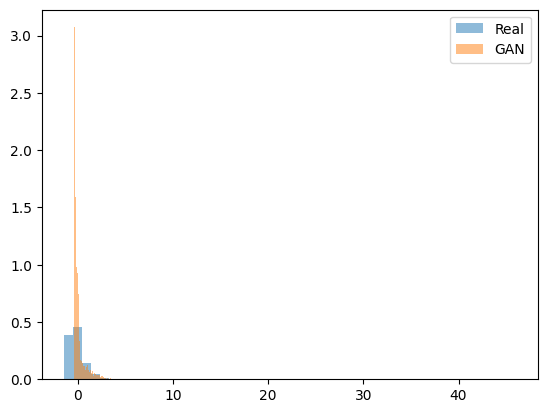

In [35]:
import matplotlib.pyplot as plt
plt.hist(real_data.numpy(), bins=50, density=True, alpha=0.5, label="Real")
plt.hist(fake_samples, bins=50, density=True, alpha=0.5, label="GAN")

plt.legend()
plt.show()
